### Data Loading and Preparation

Step 1 — Data Preparation (
data_prep.py
)
Loads two parquet files from data/raw/:
shopping_queries_dataset_examples.parquet — 2,621,288 query-product judgments
shopping_queries_dataset_products.parquet — 1,814,924 product records
Merges them on (product_locale, product_id) to get full product info per judgment
Filters to only:
The 3 target queries (specified in the exercise)
esci_label == "E" (Exact matches only)
Builds a product_context string per row by concatenating title, des

In [4]:
from src.llm import ModelEvaluator
from src.evalution import run_experiment, score_against_human
from src.prompts import EVALUATION_PROMPT
from src.schemas.response_schema import MyResponse, MyResponseReordered
from litellm import completion
from pydantic import BaseModel, Field
from typing import List
from pathlib import Path
import pandas as pd

In [5]:
# df_examples, df_products = load_raw_data('../data/raw')
# x = get_evaluation_dataset(df_examples, df_products)
subset = pd.read_csv('../data/processed/subset_to_review.csv')
subset = subset[subset.esci_label=='E']

manual_labels = pd.read_csv('../data/processed/my_manual_labels.csv')

### Prompt Engineering

#### V1 Prompt: Basic prompt with Gemma3:4b

jdasl; dasl;d jas 

In [6]:
if Path('../data/processed/gemma_labels_v0.csv').exists():
    v0_labels = pd.read_csv('../data/processed/gemma_labels_v0.csv')
else:
    gemma_v0 = ModelEvaluator(temperature=0)
    v0_labels = run_experiment(subset, gemma_v0, 'gemma_labels_v0')

In [7]:
merged_data = pd.merge(
    v0_labels,
    manual_labels.loc[:, ['example_id', 'human_label', 'human_notes', 'Conflict_Found_GT']],
    how='inner', on='example_id'
)

In [8]:
merged_data.head(5)

,example_id,original_label,query,title,brand,bullet,query_features,product_features,conflict_found,reasoning,acceptable,reformulated_query,latency_sec,error,query_id,product_id,bullets,human_label,human_notes,Conflict_Found_GT
0,142651,E,aa batteries 100 pack,Energizer Advanced AA Alkaline Bulk Battery - ...,Energizer,Bulk Packaging,"['aa batteries', '100 pack']","['Energizer', 'AA Alkaline', 'Bulk Battery', '...",False,"The query asks for ""aa batteries 100 pack"". Th...",True,NaN,15.63,NaN,NaN,NaN,NaN,E,NaN,False
1,142652,E,aa batteries 100 pack,"IMPECCA AA Batteries, All Purpose Alkaline Bat...",Impecca,Packaging may VARY! AA 1.5 volt alkaline batte...,"['aa batteries', '100 pack']","['aa 1.5 volt alkaline batteries', '100-count'...",False,The query asks for '100 pack' of AA batteries....,True,NaN,11.08,NaN,NaN,NaN,NaN,E,NaN,False
2,142653,E,aa batteries 100 pack,Allmax AA Maximum Power Alkaline Batteries (10...,Allmax Battery,★ Maximum Power – Allmax Maximum Power AA Batt...,['aa batteries 100 pack'],"['allmax aa batteries', '100 count', 'alkaline...",False,"The query asks for ""aa batteries 100 pack"". Th...",True,NaN,11.19,NaN,NaN,NaN,NaN,E,NaN,False
3,142659,E,aa batteries 100 pack,Amazon Basics 100 Pack AA High-Performance Alk...,Amazon Basics,IN THE BOX: 100-pack of 1.5 volt AA alkaline b...,"['aa batteries', '100 pack']","['aa batteries', '100 pack', 'amazon basics', ...",False,"The query asks for ""aa batteries 100 pack"". Th...",True,NaN,15.29,NaN,NaN,NaN,NaN,E,NaN,False
4,142660,E,aa batteries 100 pack,"Rayovac AA Alkaline Double A Batteries, 60 Count",Rayovac,60 pack of Rayovac High Energy Alkaline AA Bat...,"['aa batteries', '100 pack']","['rayovac', '60 count', 'aa alkaline', 'double...",True,The query asks for a 100 pack of AA batteries....,True,"rayovac aa alkaline double a batteries, 60 pack",11.17,NaN,NaN,NaN,NaN,S,aa batteries 60 pack,True


Issues here:
1. Conflict found and acceptable can sometimes be in disagreement
2. Even if no conflict found, gemma still creates a reformulated query
3. Found a case where product contains matte finish but matches with glossy and model still says it is acceptable 

In [9]:
merged_data[merged_data.example_id==142660]

,example_id,original_label,query,title,brand,bullet,query_features,product_features,conflict_found,reasoning,acceptable,reformulated_query,latency_sec,error,query_id,product_id,bullets,human_label,human_notes,Conflict_Found_GT
4,142660,E,aa batteries 100 pack,"Rayovac AA Alkaline Double A Batteries, 60 Count",Rayovac,60 pack of Rayovac High Energy Alkaline AA Bat...,"['aa batteries', '100 pack']","['rayovac', '60 count', 'aa alkaline', 'double...",True,The query asks for a 100 pack of AA batteries....,True,"rayovac aa alkaline double a batteries, 60 pack",11.17,NaN,NaN,NaN,NaN,S,aa batteries 60 pack,True


In [10]:
merged_data[merged_data.conflict_found == merged_data.acceptable]

,example_id,original_label,query,title,brand,bullet,query_features,product_features,conflict_found,reasoning,acceptable,reformulated_query,latency_sec,error,query_id,product_id,bullets,human_label,human_notes,Conflict_Found_GT
4,142660,E,aa batteries 100 pack,"Rayovac AA Alkaline Double A Batteries, 60 Count",Rayovac,60 pack of Rayovac High Energy Alkaline AA Bat...,"['aa batteries', '100 pack']","['rayovac', '60 count', 'aa alkaline', 'double...",True,The query asks for a 100 pack of AA batteries....,True,"rayovac aa alkaline double a batteries, 60 pack",11.17,NaN,NaN,NaN,NaN,S,aa batteries 60 pack,True
8,660823,E,"dewalt 8v max cordless screwdriver kit, gyrosc...","DEWALT XTREME 12V MAX Cordless Screwdriver, 1/...",DEWALT,The cordless screwdriver has 25% more power**\...,"['dewalt', '8v max cordless screwdriver kit', ...","['dewalt', '12v max cordless screwdriver', '1/...",True,The query asks for an 8v max cordless screwdri...,True,"dewalt 12v max cordless screwdriver tool only,...",12.53,NaN,NaN,NaN,NaN,S,"dewalt 12v max cordless screwdriver tool only,...",True
9,660827,E,"dewalt 8v max cordless screwdriver kit, gyrosc...","ENERTWIST Cordless Screwdriver, 8V Max 10Nm El...",ENERTWIST,【Powerful 8V Motor & Max 10Nm Torque】Enertwist...,"['8v max cordless screwdriver kit, gyroscopic']","['8V Max', '10Nm Torque', '21+1 Cluth', 'LED L...",True,The query asks for an 8v max cordless screwdri...,True,enertwist 8v max cordless screwdriver tool onl...,12.06,NaN,NaN,NaN,NaN,S,"enertwist 8v max cordless screwdriver kit, gyr...",True
10,660833,E,"dewalt 8v max cordless screwdriver kit, gyrosc...",DEWALT DCF680N2 8V Max Gyroscopic Screwdriver ...,DEWALT,Motion-activated Variable Speed & Reversing Co...,"['dewalt 8v max cordless screwdriver kit, gyro...",['DEWALT DCF680N2 8V Max Gyroscopic Screwdrive...,True,The query asks for an 8v max cordless screwdri...,True,dewalt 8v max cordless screwdriver 2 battery k...,12.54,NaN,NaN,NaN,NaN,E,NaN,False
11,660838,E,"dewalt 8v max cordless screwdriver kit, gyrosc...",DEWALT DCB095 8V MAX Battery Charger,DEWALT,Charges all DEWALT 8V MAX Li-Ion batteries\nCh...,"['8v max cordless screwdriver kit', 'gyroscopic']","['8v max', 'DEWALT', 'battery charger', 'LED i...",True,The query asks for an 8v max cordless screwdri...,True,"dewalt 8v max battery charger, gyroscopic",11.28,NaN,NaN,NaN,NaN,C,dewalt 8v max battery charger,True
12,660840,E,"dewalt 8v max cordless screwdriver kit, gyrosc...","DEWALT 8V MAX Cordless Screwdriver Kit, Gyrosc...",DEWALT,The cordless screwdriver features motion activ...,"['dewalt 8v max cordless screwdriver kit, gyro...","['DEWALT 8V MAX Cordless Screwdriver Kit, Gyro...",True,The query specifies an 8v max kit. The product...,True,"dewalt 8v max cordless screwdriver kit, gyrosc...",11.55,NaN,NaN,NaN,NaN,E,NaN,False
13,660842,E,"dewalt 8v max cordless screwdriver kit, gyrosc...","DEWALT 8V MAX Cordless Screwdriver Kit, Gyrosc...",DEWALT,The cordless screwdriver features motion activ...,"['dewalt 8v max cordless screwdriver kit, gyro...","['DEWALT 8V MAX Cordless Screwdriver Kit, Gyro...",True,The query specifies an 8v max kit. The product...,True,"dewalt 8v max cordless screwdriver kit, gyrosc...",11.56,NaN,NaN,NaN,NaN,E,NaN,False
15,1163629,E,kodak photo paper 8.5 x 11 glossy,"Kodak photo paper 8.5 x 11 matte, 100 count 39...",KODAK,NaN,"['kodak', 'photo paper', '8.5 x 11', 'glossy']","['kodak', 'photo paper', '8.5 x 11', 'matte', ...",True,"The query asks for glossy photo paper, but the...",True,kodak photo paper 8.5 x 11 glossy,9.61,NaN,NaN,NaN,NaN,S,kodak photo paper 8.5 x 11 matte,True
17,1163634,E,kodak photo paper 8.5 x 11 glossy,"Kodak 8209017 Photo Paper, 6.5 mil, Glossy, 8-...",Doaaler,Sold as 100 Sheets/Pack.\nInstant dry.\nNo sme...,"['kodak', 'photo paper', '8.5 x 11', 'glossy']","['kodak', '8-1/2 x 11', 'glossy', '100 sheets/...",False,"The query asks for ""kodak photo paper 8.5 x 11...",False,NaN,10.33,NaN,NaN,NaN,NaN,E,NaN,False


In [11]:
merged_data[merged_data.example_id == 1163641]

,example_id,original_label,query,title,brand,bullet,query_features,product_features,conflict_found,reasoning,acceptable,reformulated_query,latency_sec,error,query_id,product_id,bullets,human_label,human_notes,Conflict_Found_GT
21,1163641,E,kodak photo paper 8.5 x 11 glossy,"Kodak Photo Paper for inkjet printers, Matte F...",KODAK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,litellm.APIConnectionError: OllamaException - ...,58953.0,B000EZ0CTK,"Basic matte paper for arts, craft and snapshot...",S,kodak photo paper 8.5 x 11 matte,True


In [12]:
merged_data[merged_data.conflict_found != merged_data.Conflict_Found_GT]

,example_id,original_label,query,title,brand,bullet,query_features,product_features,conflict_found,reasoning,acceptable,reformulated_query,latency_sec,error,query_id,product_id,bullets,human_label,human_notes,Conflict_Found_GT
5,142661,E,aa batteries 100 pack,Energizer AA Max Alkaline E91 Batteries Made i...,Energizer,Made in USA\nUp to 10 years shelf life\nZero M...,"['aa batteries', '100 pack']","['Energizer AA Max Alkaline', '100 count', '50...",False,"The query asks for ""aa batteries 100 pack"". Th...",True,NaN,11.57,NaN,NaN,NaN,NaN,S,aa batteries 50 pack,True
10,660833,E,"dewalt 8v max cordless screwdriver kit, gyrosc...",DEWALT DCF680N2 8V Max Gyroscopic Screwdriver ...,DEWALT,Motion-activated Variable Speed & Reversing Co...,"['dewalt 8v max cordless screwdriver kit, gyro...",['DEWALT DCF680N2 8V Max Gyroscopic Screwdrive...,True,The query asks for an 8v max cordless screwdri...,True,dewalt 8v max cordless screwdriver 2 battery k...,12.54,NaN,NaN,NaN,NaN,E,NaN,False
12,660840,E,"dewalt 8v max cordless screwdriver kit, gyrosc...","DEWALT 8V MAX Cordless Screwdriver Kit, Gyrosc...",DEWALT,The cordless screwdriver features motion activ...,"['dewalt 8v max cordless screwdriver kit, gyro...","['DEWALT 8V MAX Cordless Screwdriver Kit, Gyro...",True,The query specifies an 8v max kit. The product...,True,"dewalt 8v max cordless screwdriver kit, gyrosc...",11.55,NaN,NaN,NaN,NaN,E,NaN,False
13,660842,E,"dewalt 8v max cordless screwdriver kit, gyrosc...","DEWALT 8V MAX Cordless Screwdriver Kit, Gyrosc...",DEWALT,The cordless screwdriver features motion activ...,"['dewalt 8v max cordless screwdriver kit, gyro...","['DEWALT 8V MAX Cordless Screwdriver Kit, Gyro...",True,The query specifies an 8v max kit. The product...,True,"dewalt 8v max cordless screwdriver kit, gyrosc...",11.56,NaN,NaN,NaN,NaN,E,NaN,False
18,1163638,E,kodak photo paper 8.5 x 11 glossy,"Kodak Photo Paper for inkjet printers, Gloss F...",KODAK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,litellm.APIConnectionError: OllamaException - ...,58953.0,B000EZTYHG,"Instant dry. For quality, colorful prints. Aff...",E,NaN,False
21,1163641,E,kodak photo paper 8.5 x 11 glossy,"Kodak Photo Paper for inkjet printers, Matte F...",KODAK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,litellm.APIConnectionError: OllamaException - ...,58953.0,B000EZ0CTK,"Basic matte paper for arts, craft and snapshot...",S,kodak photo paper 8.5 x 11 matte,True


              precision    recall  f1-score   support

 No Conflict       0.93      0.81      0.87        16
    Conflict       0.62      0.83      0.71         6

    accuracy                           0.82        22
   macro avg       0.78      0.82      0.79        22
weighted avg       0.85      0.82      0.83        22



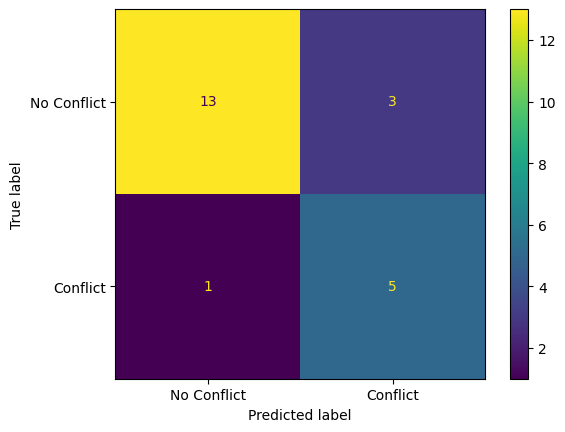

In [13]:
score_against_human(merged_data)

#### V1 Prompt: Basic prompt with Qwen2:7b
Same prompt -- model changed from gemma3:4b to qwen2:7b

In [ ]:
if Path('../data/processed/qwen_labels_v0.csv').exists():
    v0_qwen_labels = pd.read_csv('../data/processed/qwen_labels_v0.csv')
else:
    gemma_v0 = ModelEvaluator(model_name='ollama/qwen2:7b', temperature=0, response_schema=MyResponseReordered)
    v0_qwen_labels = run_experiment(subset, gemma_v0, 'qwen_labels_v0')

In [ ]:
merged_data_qwen = pd.merge(
    v0_qwen_labels,
    manual_labels.loc[:, ['example_id', 'human_label', 'human_notes', 'Conflict_Found_GT']],
    how='inner', on='example_id'
)
score_against_human(merged_data_qwen)